# Steady-state beam spread on the exit face &mdash; random slab 250$\times$250$\times$32 $\mu$m
Two width estimators of the transmitted intensity, per CW frequency bin: the second moment
$\sigma^2(\nu)$ and the participation-ratio diameter $d(\nu)$, both in units of $a$, against the
**fully-diffusive prediction** and the **independently measured** transmission $T(\nu)$.
Nothing is derived from the field data twice, and nothing in the baseline is guessed: the gap
comes from the MPB run, $T(\nu)$ from the transmission run, and
$\ell^*(\nu)=\ell_s(\nu)/(1-g(\nu))$ with $z_0(\nu)$ from the measured $\ell_s$, $g$ and filling
fraction. Physics, verdicts and systematics: `README.md`.

In [11]:
# --- constants, paths, MPB gap, measured transmission (facts: README.md) ------
import os, sys, gc, time
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from scipy.integrate import simpson
from scipy.special import j0
sys.path.append(os.path.abspath(r'../../../../../tidy3d'))
import AutomationModule as AM
plt.rc('font', family='Arial')

a       = 2.562629142772549   # unit length a [um]   (nu = a f / c)
L_slab  = 32.0                # slab thickness [um]  = 12.487 a
n_index = "2.90"              # <-- pick the run: "3.30" | "2.90" | "2.40"
FILES = {   # exit-face field monitors (all three runs are on disk)
    "3.30": "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_3p3_backdround_effective_n_1.00.h5",
    "2.90": "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_2p9_background_effective_n_1.00.h5",
    "2.40": "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_2p4_background_effective_n_1.00.h5",
}
file_data = FILES[n_index]

# MPB gap of the PERIODIC PARENT lattice: a design/reference window, NOT a
# measurement on this aperiodic slab.  Same conversion as 20260808_..._time.ipynb.
gap_data = AM.read_hdf5_as_dict(r"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gk  = gap_data["Circular"]["0.22"]
ig  = np.where(np.isclose(gk["n"], float(n_index)))[0]        # isclose: n is float
GAP = tuple(a/(14.3/gk["gap_edges"][ig].flatten()))

# Measured transmission spectrum, from its own run.  It replaces the old S_rel
# envelope-fit proxy entirely: no gap finding and no validity mask are derived
# from the fields any more.
transmission_data = AM.read_hdf5_as_dict(
    "./data/slab_250x250x32/Transmission/LSU_20260804_slab_250x250x32_Transmission_background_n_1.00.h5")
_T = transmission_data.get(n_index)
if _T is None:                       # e.g. n = 3.30: that run has NOT been done yet
    T_nu = T_val = None
    print(f"!! NO transmission run for n = {n_index} (groups on file: {sorted(transmission_data)}).\n"
          "   The T(nu) panel stays empty.  To fill it: run 20251001_..._transmission.py,\n"
          "   then retrieve with 20251007_Retireve_Transmission_Data.ipynb.")
else:
    T_nu  = a*np.asarray(_T["f"], float)/td.C_0               # its OWN nu axis --
    T_val = np.asarray(_T["Transmission_Exit"], float)        # never interpolated
    print(f"transmission: {T_nu.size} bins, nu = [{T_nu[0]:.3f}, {T_nu[-1]:.3f}], "
          f"T = [{T_val.min():.2e}, {T_val.max():.2e}]")
print(f"n = {n_index}   MPB gap = [{GAP[0]:.4f}, {GAP[1]:.4f}]   {os.path.basename(file_data)}")

transmission: 250 bins, nu = [0.390, 0.500], T = [1.89e-06, 1.58e-01]
n = 2.90   MPB gap = [0.4321, 0.4601]   LSU_20260804_slab_250x250x32_n_2p9_background_effective_n_1.00.h5


In [12]:
# --- exit-face fields -> RAM; axes; Simpson weights; estimators + unit tests ---
# read_hdf5_as_dict is NOT lazy: it materialises Ex, Ey, Ez (~9.5 GB for n=3.30).
# Every axis is re-read from the h5 -- grid size, nu range and bin count differ
# between runs (n = 2.40 only covers nu = 0.47-0.53).
t0 = time.time()
data = AM.read_hdf5_as_dict(file_data)
Ex_, Ey_, Ez_ = data[n_index]["Ex"], data[n_index]["Ey"], data[n_index]["Ez"]   # (nx,ny,1,N)
xg = np.asarray(data[n_index]["x"], float)          # NON-uniform grid ->
yg = np.asarray(data[n_index]["y"], float)          # product-Simpson weights
nu = a*np.asarray(data[n_index]["f"], float)/td.C_0                 # ascending
nx, ny, N = xg.size, yg.size, nu.size
wxS = simpson(np.eye(nx), x=xg, axis=1)             # exact on the true grid
wyS = simpson(np.eye(ny), x=yg, axis=1)
AW  = wxS[:, None]*wyS[None, :]
Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
Rg2 = Xg**2 + Yg**2; Rg = np.sqrt(Rg2)              # rho about the injection axis

# Per-bin estimators of the transverse spread.  Both are invariant under
# I -> c I, so the raw-DFT source envelope (normalize_index=None) cancels.
# Their systematics are complementary, and that is the reason to plot both:
#   sigma^2 : true second moment.  A uniform floor biases it UP, an aperture cut
#             biases it DOWN -- ~36x resp. ~5-24x harder than d, because of the
#             rho^2 weight.  It is UNBIASED by speckle.
#   d       : participation-ratio diameter 2 sqrt(A_eff/pi).  Same signs but far
#             more tolerant (tolerant, NOT immune: +7% at a 1e-3 uniform floor),
#             and biased LOW by ~x1.15-1.20 on a SINGLE speckle realization
#             (ensemble = raw x sqrt(1+C^2), C = resolved speckle contrast).
def sig2_of(S1, M2): return (M2/S1)/a**2                    # [a^2]
def d_of(S1, S2):    return 2*np.sqrt((S1**2/S2)/np.pi)/a   # [a]

for s in (5.0, 12.0, 20.0):     # unit test: I = exp(-rho^2/2s^2) -> d = 4s, sigma^2 = 2 s^2
    Ig = np.exp(-Rg2/(2*s*s))
    S1_, S2_, M2_ = (Ig*AW).sum(), (Ig**2*AW).sum(), (Rg2*Ig*AW).sum()
    assert abs(d_of(S1_, S2_)*a/(4*s) - 1) < 1e-4, s
    assert abs(sig2_of(S1_, M2_)*a**2/(2*s*s) - 1) < 1e-4, s
print(f"grid {nx}x{ny}, nu = [{nu[0]:.4f}, {nu[-1]:.4f}] in {N} bins "
      f"(dnu = {np.mean(np.diff(nu)):.2e}); loaded in {time.time()-t0:.0f} s\n"
      "Gaussian unit tests OK:  d = 4s  and  sigma^2 = 2 s^2")

grid 438x438, nu = [0.3300, 0.5000] in 1394 bins (dnu = 1.22e-04); loaded in 2 s
Gaussian unit tests OK:  d = 4s  and  sigma^2 = 2 s^2


In [13]:
# --- ONE streaming pass over the fields: S1, S2, M2 and the rim fraction -------
# I = |Ex|^2+|Ey|^2+|Ez|^2 ;  S1 = int I dA,  S2 = int I^2 dA,  M2 = int rho^2 I dA.
# Blocked by rows (BL ~ 33) with a gc per block: the temporaries, not the fields,
# are what would blow the RAM.  |E| ~ 1e-15..1e-23, so I is built in float64
# (a float32 |E|^2 goes subnormal); the scale SC cancels in every estimator.
t0 = time.time(); BL = 33; SC = 1e15
S1 = np.zeros(N); S2 = np.zeros(N); M2 = np.zeros(N); Prim = np.zeros(N)
wyS_y2 = wyS*yg**2
RIM = Rg > 45*a                    # rim ring: aperture-saturation warning only
for i0 in range(0, nx, BL):
    i1 = min(i0+BL, nx)
    I  = (np.abs(Ex_[i0:i1, :, 0, :]).astype(np.float64)*SC)**2
    I += (np.abs(Ey_[i0:i1, :, 0, :]).astype(np.float64)*SC)**2
    I += (np.abs(Ez_[i0:i1, :, 0, :]).astype(np.float64)*SC)**2
    wxb = wxS[i0:i1]
    Ay  = np.tensordot(I,    wyS,    axes=([1], [0]))       # int . dy
    A2y = np.tensordot(I**2, wyS,    axes=([1], [0]))
    By  = np.tensordot(I,    wyS_y2, axes=([1], [0]))       # int y^2 . dy
    S1 += (wxb[:, None]*Ay).sum(0)                          # then int . dx
    S2 += (wxb[:, None]*A2y).sum(0)
    M2 += (wxb[:, None]*((xg[i0:i1]**2)[:, None]*Ay + By)).sum(0)
    m = RIM[i0:i1]
    if m.any(): Prim += np.einsum("pn,p->n", I[m], (wxb[:, None]*wyS[None, :])[m])
    del I, Ay, A2y, By; gc.collect()
    print(f"rows {i1}/{nx}", end="\r")
sig2, d_nu, rim = sig2_of(S1, M2), d_of(S1, S2), Prim/S1
INGAP = (nu >= GAP[0]) & (nu <= GAP[1])
MID   = nu >= GAP[1] + 0.025                    # smooth band well above the gap
if MID.sum() < 20: MID = nu >= nu[0] + 0.8*(nu[-1] - nu[0])
print(f"\none pass over {nx}x{ny}x{N} in {time.time()-t0:.0f} s")
print(f"mid-band nu = [{nu[MID][0]:.3f}, {nu[MID][-1]:.3f}]: median sigma^2 = {np.median(sig2[MID]):.0f} a^2, "
      f"median d = {np.median(d_nu[MID]):.1f} a  (ensemble d = raw x 1.15-1.20 -> "
      f"{1.15*np.median(d_nu[MID]):.1f}-{1.20*np.median(d_nu[MID]):.1f} a)")
print(f"rim power (rho > 45a): median {100*np.median(rim[MID]):.2f}% mid-band, "
      f"{100*np.median(rim[INGAP]):.1f}% inside the MPB gap; "
      f"{100*(rim > 0.02).mean():.0f}% of all bins are above the 2% aperture-saturation flag")

rows 438/438
one pass over 438x438x1394 in 8 s
mid-band nu = [0.485, 0.500]: median sigma^2 = 146 a^2, median d = 22.7 a  (ensemble d = raw x 1.15-1.20 -> 26.1-27.2 a)
rim power (rho > 45a): median 0.07% mid-band, 1.5% inside the MPB gap; 18% of all bins are above the 2% aperture-saturation flag


In [4]:
# --- diffusive baseline from the MEASURED ls(nu) and g(nu) -- nothing guessed --
# Extrapolated-boundary slab kernel T(q) = sinh(q(l*+z0)) cosh(q z0)/sinh(q(L+2 z0))
# (z0 = 0 -> Cherroret PRE 82 056603 Eq. 3).  Its small-q expansion gives the
# second moment EXACTLY:
#     sigma^2_dif = (2/3)[(L+2z0)^2 - (l*+z0)^2] - 2 z0^2
#                 = (2/3)(L^2 - l*^2) + (4/3) z0 (2L - l*)      <- the z0^2 cancels
# (asserted below against a direct Hankel transform of the same kernel).
# Both inputs now come from measured/derived quantities, per frequency bin:
#   l*(nu) = ls(nu)/(1 - g(nu))   ls from the mean-free-path runs, g from the
#                                 structure-factor runs (../data/{ls,g}_values)
#   z0(nu) = (2/3) l*(nu) (1+R)/(1-R),  R = angle-averaged internal reflectance
#            (Zhu-Pine-Weitz) of the SAME medium, n_eff = Maxwell-Garnett from the
#            measured ff and n_rod.  R is validated in-cell against Haskell 1994.
# SCALE TRAP -- the two transport runs do NOT share a convention (each branch is
# self-checked: the ls minimum must land inside the MPB gap):
#   n=3.30: ls run at the NATIVE scale a' = 0.8a  -> nu = 0.8 a f/c, lengths x1.25
#   n=2.90: ls run at the SLAB scale a            -> nu = linspace(0.32, 1.25), as-is
#   n=3.30: g file nu co-stored ASCENDING (nu*lambda = a')
#   n=2.90: g file nu and g co-stored DESCENDING  -> reverse both
# CAVEAT: g is Born/RDG single-scattering (the generator warns |m-1| >> 0.1), so
# l*(nu) is indicative; sigma^2_dif is dominated by L and z0, so the LEVEL is robust.
FF   = 0.2237                          # measured filling fraction of the network
NROD = {"3.30": 3.30, "2.90": 2.90}    # rod index of each run

def sig2_dif(lt, z0=0.0):              # closed form, vectorised over nu
    return ((2/3)*((L_slab + 2*z0)**2 - (lt + z0)**2) - 2*z0**2)/a**2
def T_rho(lt, z0, r, nq=4000):
    """exit-face transverse profile = 2D inverse Hankel transform of T(q)."""
    Cc, A, B = L_slab + 2*z0, lt + z0, z0
    q = np.linspace(1e-12, min(80.0/(Cc - A - B), 700.0/Cc), nq)   # T(q) ~ exp(-q(Cc-A-B))
    Tq = np.sinh(q*A)*np.cosh(q*B)/np.sinh(q*Cc)
    out = np.empty(r.size)
    for s0 in range(0, r.size, 512):                               # chunked: j0() is the cost
        sl = slice(s0, s0 + 512)
        out[sl] = simpson(j0(np.outer(r[sl], q))*(Tq*q), x=q, axis=1)/(2*np.pi)
    return out
def dif_pair(lt, z0=0.0, nr=1200):
    """(d, sigma^2) of the diffusive profile through the SAME estimators and grid,
    plus the infinite-plane sigma^2 used to cross-check the closed form."""
    r  = np.linspace(0.0, 6*(L_slab + 2*z0), nr)
    Tr = np.clip(T_rho(lt, z0, r), 0, None)
    I  = np.interp(Rg.ravel(), r, Tr, right=0.0).reshape(Rg.shape)
    s1, s2, m2 = (I*AW).sum(), (I**2*AW).sum(), (Rg2*I*AW).sum()
    return d_of(s1, s2), sig2_of(s1, m2), (simpson(Tr*r**3, x=r)/simpson(Tr*r, x=r))/a**2
def n_eff_MG(n_rod, f):                # Maxwell-Garnett from the measured ff
    b = f*(n_rod**2 - 1)/(n_rod**2 + 2)
    return np.sqrt((1 + 2*b)/(1 - b))
def R_internal(n_in, N=100001):        # Zhu-Pine-Weitz angle-averaged reflectance
    th = np.linspace(0, np.pi/2, N); s = n_in*np.sin(th)
    c1 = np.cos(th); c2 = np.sqrt(np.clip(1 - s**2, 0, None))
    R  = 0.5*(((n_in*c1 - c2)/(n_in*c1 + c2))**2 + ((n_in*c2 - c1)/(n_in*c2 + c1))**2)
    R[s >= 1] = 1.0                    # total internal reflection
    R1 = simpson(2*R*np.sin(th)*np.cos(th),    x=th)
    R2 = simpson(3*R*np.sin(th)*np.cos(th)**2, x=th)
    return (R1 + R2)/(2 - R1 + R2)
assert abs(R_internal(1.33) - 0.431) < 2e-3        # Haskell 1994 Table 2 / Zhu-Pine-Weitz
_ = dif_pair(L_slab/10, 0.0)                       # closed form vs numerical Hankel
assert abs(_[2]/sig2_dif(L_slab/10, 0.0) - 1) < 5e-3, "closed form vs Hankel transform"

def transport_mfp(ni):
    """measured (ls, g) interpolated onto the field nu axis, at the SLAB scale."""
    if ni == "3.30":
        rf   = np.asarray(AM.read_hdf5_as_dict(
            r"../20251029_T(L)/data/20251030_ff_2237_circular_rods_n_3p3_2.h5")["raw_freqs"], float)
        nu_l = 0.8*a*rf/td.C_0                                   # ls run at a' = 0.8 a
        ls   = 1.25*np.asarray(AM.read_hdf5_as_dict(
            r"../data/ls_values/20251031_ls_values_n_3p3.h5")["0.2237"], float)   # -> slab scale
        gd   = AM.read_hdf5_as_dict(r"../data/g_values/n_3.3_ff_0.2237_g_data.h5")
        nu_g = np.asarray(gd["nu"], float)                       # ASCENDING
        g    = np.asarray(gd["file4_N100000"]["g_avg"], float)
        assert np.interp(nu, nu_g, np.asarray(gd["file4_N100000"]["reliable"], float)).min() > 0.99
    elif ni == "2.90":
        nu_l = np.linspace(0.32, 1.25, 1700)                     # ls run at the SLAB scale a
        ls   = np.asarray(AM.read_hdf5_as_dict(
            r"../data/ls_values/20260608_ls_values_n_2p9.h5")["0.2237"], float)
        gd   = AM.read_hdf5_as_dict(r"../data/g_values/n_2.90_ff_0.2237_g_data.h5")
        nu_g = np.asarray(gd["nu"], float)[::-1]                 # DESCENDING on file
        g    = np.asarray(gd["g"], float)[::-1]
    else:
        return None, None
    assert GAP[0] <= nu_l[np.argmin(ls)] <= GAP[1], "ls(nu) axis convention"   # self-check
    return np.interp(nu, nu_l, ls), np.interp(nu, nu_g, g)

t0 = time.time()
ls_nu, g_nu = transport_mfp(n_index)
if ls_nu is None:
    LSTAR = Z0 = S2_DIF = S2_DIF0 = D_DIF = D_DIF0 = None
    DIFOK = np.zeros(N, bool)
    print(f"!! no ls/g transport run for n = {n_index} -> no diffusive baseline is drawn.")
else:
    LSTAR = ls_nu/(1 - g_nu)                                     # transport mean free path [um]
    NEFF  = n_eff_MG(NROD[n_index], FF); RE = R_internal(NEFF)
    ZK    = (2/3)*(1 + RE)/(1 - RE)                              # z0/l*, no free parameter
    Z0    = ZK*LSTAR
    S2_DIF, S2_DIF0 = sig2_dif(LSTAR, Z0), sig2_dif(LSTAR, 0.0)
    knots = np.geomspace(LSTAR.min(), LSTAR.max(), 20)           # d_dif depends on l* alone
    D_DIF  = np.interp(LSTAR, knots, [dif_pair(v, ZK*v)[0] for v in knots])
    D_DIF0 = np.interp(LSTAR, knots, [dif_pair(v, 0.0)[0]  for v in knots])
    DIFOK = LSTAR <= L_slab/4                                    # diffusion needs l* << L
    print(f"n_eff (Maxwell-Garnett, ff = {FF}, n_rod = {NROD[n_index]}) = {NEFF:.4f} -> "
          f"R_int = {RE:.3f}, z0/l* = {ZK:.3f}  [{time.time()-t0:.0f} s]")
    print(f"measured l*(nu) over the band: {LSTAR.min():.2f}-{LSTAR.max():.2f} um "
          f"(L/l* = {L_slab/LSTAR.max():.1f}-{L_slab/LSTAR.min():.1f}); "
          f"{100*(~DIFOK).mean():.0f}% of bins have l* > L/4 -> diffusion marginal, baseline hidden there")
    print(f"mid-band [{nu[MID][0]:.3f}, {nu[MID][-1]:.3f}]: l* = {np.median(LSTAR[MID]):.2f} um, "
          f"z0 = {np.median(Z0[MID]):.2f} um  ->  sigma^2_dif = {np.median(S2_DIF[MID]):.0f} a^2 "
          f"(z0=0: {np.median(S2_DIF0[MID]):.0f}),  d_dif = {np.median(D_DIF[MID]):.1f} a "
          f"(z0=0: {np.median(D_DIF0[MID]):.1f})")

n_eff (Maxwell-Garnett, ff = 0.2237, n_rod = 3.3) = 1.2734 -> R_int = 0.373, z0/l* = 1.461  [22 s]
measured l*(nu) over the band: 1.07-8.51 um (L/l* = 3.8-29.8); 0% of bins have l* > L/4 -> diffusion marginal, baseline hidden there
mid-band [0.460, 0.500]: l* = 4.74 um, z0 = 6.92 um  ->  sigma^2_dif = 185 a^2 (z0=0: 102),  d_dif = 33.8 a (z0=0: 25.9)

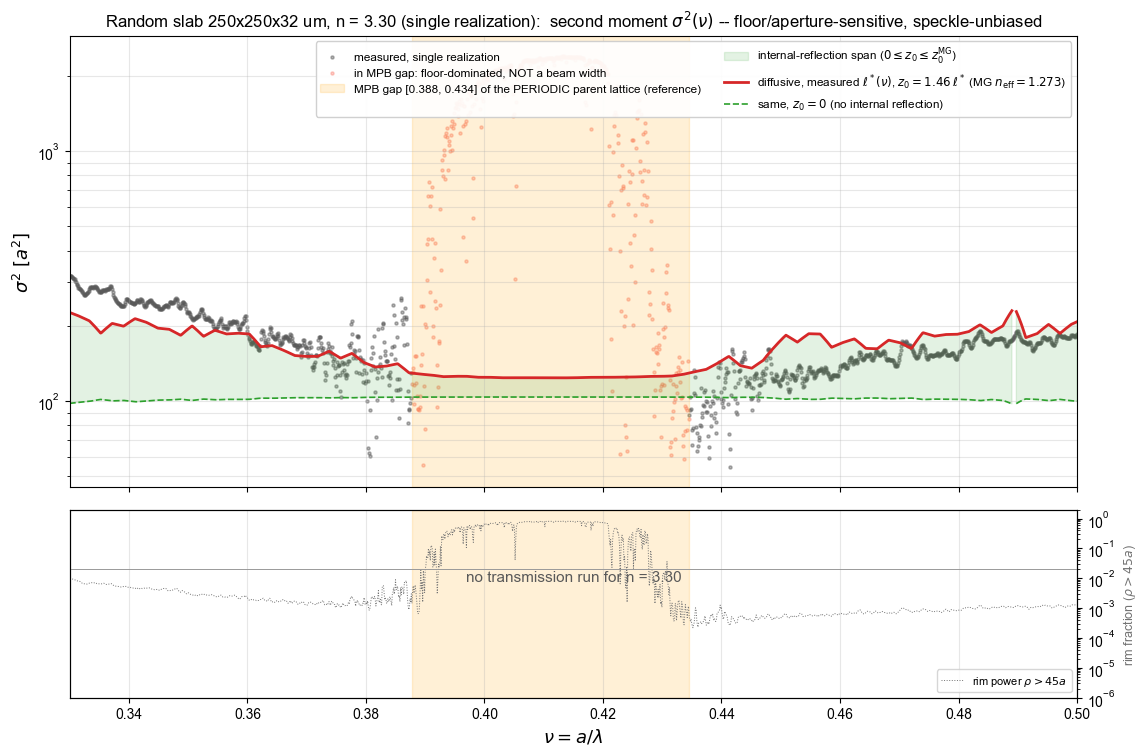

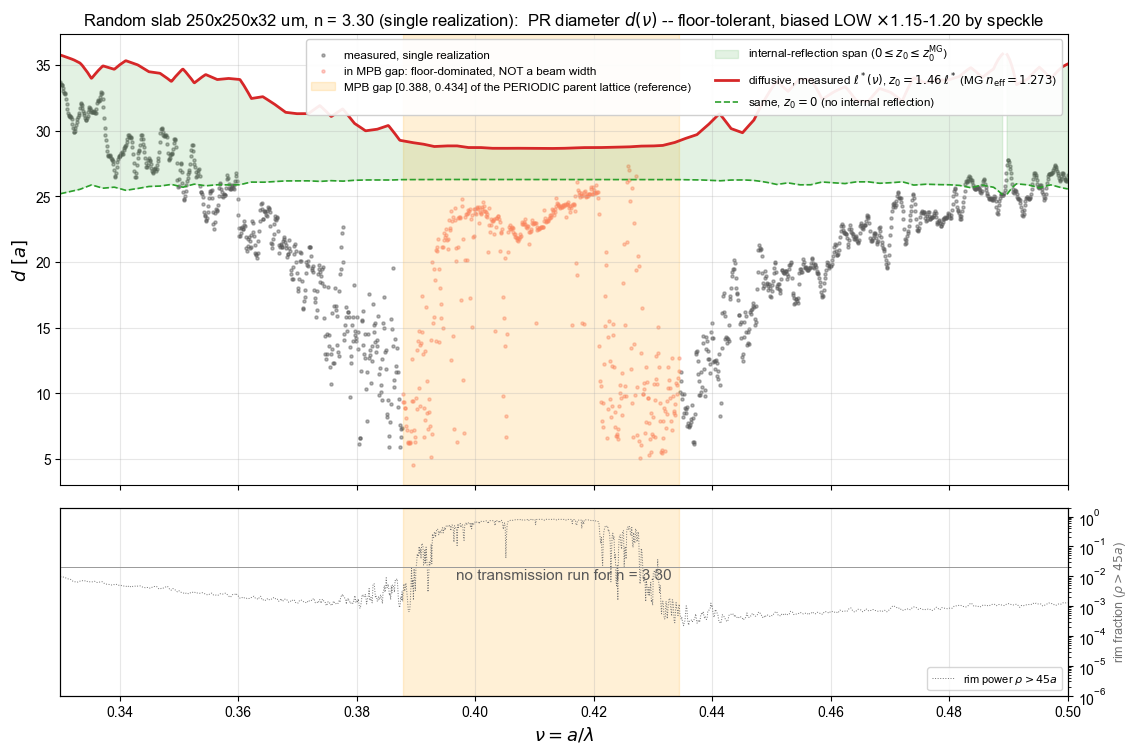

mid-band [0.460, 0.500], l* = 4.73 um:
  sigma^2 = 164 a^2 (speckle-unbiased)     vs diffusive 185 a^2 (z0=0: 102)   ratio 0.89
  d       = 23.9 a raw -> ensemble 27.5-28.7 a  vs diffusive 33.8 a (z0=0: 25.9)   ratio 0.81-0.85
GUARDRAIL: a CW width dip near a gap edge gives an attenuation/confinement length, NOT xi -- absorption and
  Bragg attenuation both give sigma^2 ~ 2 L L_att, and a single L cannot separate them.

In [5]:
# --- Figures 1 & 2: sigma^2(nu) and d(nu) vs the diffusive baseline and T(nu) ---
def summary_figure(y, base, base0, ylab, title, logy):
    fig, (ax, axb) = plt.subplots(2, 1, figsize=(13, 8.6), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1.25], "hspace": 0.07})
    ax.scatter(nu[~INGAP], y[~INGAP], s=5, alpha=.45, color="0.35",
               label="measured, single realization")
    ax.scatter(nu[INGAP], y[INGAP], s=5, alpha=.40, color="salmon",
               label="in MPB gap: floor-dominated, NOT a beam width")
    ax.axvspan(*GAP, color="orange", alpha=.16,
               label=f"MPB gap [{GAP[0]:.3f}, {GAP[1]:.3f}] of the PERIODIC parent lattice (reference)")
    if base is not None:      # fully-diffusive prediction from the MEASURED l*(nu)
        b, b0 = np.where(DIFOK, base, np.nan), np.where(DIFOK, base0, np.nan)
        ax.fill_between(nu, b0, b, color="tab:green", alpha=.13,
                        label=r"internal-reflection span ($0\leq z_0\leq z_0^{\rm MG}$)")
        ax.plot(nu, b, "-", lw=2, color="tab:red",
                label=rf"diffusive, measured $\ell^*(\nu)$, $z_0={ZK:.2f}\,\ell^*$ (MG $n_{{\rm eff}}={NEFF:.3f}$)")
        ax.plot(nu, b0, "--", lw=1.2, color="tab:green",
                label=r"same, $z_0=0$ (no internal reflection)")
    if logy: ax.set_yscale("log")
    ax.set_ylabel(ylab, fontsize=13); ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8.5, loc="upper right", ncol=2, framealpha=.92)
    ax.grid(alpha=.3, which="both")
    # measured T(nu) on ITS OWN nu axis (supports differ -- never interpolated),
    # plus the rim power fraction as the aperture-saturation warning.
    if T_val is not None:
        axb.semilogy(T_nu, T_val, lw=.9, color="m", label=r"measured $T(\nu)$")
        axb.set_ylabel(r"$T(\nu)$", fontsize=11, color="m")
        axb.set_ylim(.4*T_val.min(), 3*T_val.max())
    else:
        axb.text(.5, .62, f"no transmission run for n = {n_index}", transform=axb.transAxes,
                 ha="center", fontsize=11, color="0.35")
        axb.set_yticks([])
    axb.axvspan(*GAP, color="orange", alpha=.16)
    axr = axb.twinx()
    axr.semilogy(nu, np.maximum(rim, 1e-6), lw=.7, color="0.45", ls=":",
                 label=r"rim power $\rho>45a$")
    axr.axhline(2e-2, color="0.6", lw=.7)
    axr.set_ylabel(r"rim fraction ($\rho>45a$)", fontsize=9, color="0.45"); axr.set_ylim(1e-6, 2)
    axb.set_xlabel(r"$\nu = a/\lambda$", fontsize=13); axb.set_xlim(nu[0], nu[-1])
    axb.grid(alpha=.3, which="both")
    hl = axb.get_legend_handles_labels()[0] + axr.get_legend_handles_labels()[0]
    axb.legend(hl, [h.get_label() for h in hl], fontsize=8, loc="lower right")
    plt.show()

head = f"Random slab 250x250x32 um, n = {n_index} (single realization)"
summary_figure(sig2, S2_DIF, S2_DIF0, r"$\sigma^2\ [a^2]$",
               head + r":  second moment $\sigma^2(\nu)$ -- floor/aperture-sensitive, speckle-unbiased",
               logy=True)
summary_figure(d_nu, D_DIF, D_DIF0, r"$d\ [a]$",
               head + r":  PR diameter $d(\nu)$ -- floor-tolerant, biased LOW $\times$1.15-1.20 by speckle",
               logy=False)
if S2_DIF is not None:
    ok = MID & DIFOK
    ds, dd = np.median(sig2[ok]), np.median(d_nu[ok])
    bs, bd = np.median(S2_DIF[ok]), np.median(D_DIF[ok])
    print(f"mid-band [{nu[ok][0]:.3f}, {nu[ok][-1]:.3f}], l* = {np.median(LSTAR[ok]):.2f} um:")
    print(f"  sigma^2 = {ds:.0f} a^2 (speckle-unbiased)     vs diffusive {bs:.0f} a^2 "
          f"(z0=0: {np.median(S2_DIF0[ok]):.0f})   ratio {ds/bs:.2f}")
    print(f"  d       = {dd:.1f} a raw -> ensemble {1.15*dd:.1f}-{1.20*dd:.1f} a  vs diffusive {bd:.1f} a "
          f"(z0=0: {np.median(D_DIF0[ok]):.1f})   ratio {1.15*dd/bd:.2f}-{1.20*dd/bd:.2f}")
print("GUARDRAIL: a CW width dip near a gap edge gives an attenuation/confinement length, NOT xi -- "
      "absorption and\n  Bragg attenuation both give sigma^2 ~ 2 L L_att, and a single L cannot separate them.")

In [6]:
# --- interactive exit-face map: slider over frequency bins (one bin from RAM) ---
import ipywidgets as W
from IPython.display import display
def show_map(k):
    I = (np.abs(Ex_[:, :, 0, k])**2 + np.abs(Ey_[:, :, 0, k])**2
         + np.abs(Ez_[:, :, 0, k])**2).astype(np.float64)
    In = I/I.max()                                   # per-frequency normalization
    fig = plt.figure(figsize=(12.5, 7.2))
    gs = fig.add_gridspec(2, 2, height_ratios=[14, 2.0], hspace=0.33)
    for j, (ttl, Zm, vmin, vmax) in enumerate((
            (r"linear   $I/I_{\max}$", In, 0, 1),
            (r"log$_{10}(I/I_{\max})$   (floor $10^{-6}$)", np.log10(np.maximum(In, 1e-6)), -6, 0))):
        axm = fig.add_subplot(gs[0, j])
        pm = axm.pcolormesh(xg, yg, Zm.T, vmin=vmin, vmax=vmax, cmap="inferno", shading="auto")
        axm.set_aspect("equal"); axm.set_title(ttl, fontsize=11)
        axm.set_xlabel(r"x [$\mu$m]"); axm.set_ylabel(r"y [$\mu$m]" if j == 0 else "")
        axm.add_patch(plt.Rectangle((-125, -125), 250, 250, fill=False, ec="w", lw=.8, ls=":"))
        sx = axm.secondary_xaxis("top",   functions=(lambda v: v/a, lambda v: v*a))
        sy = axm.secondary_yaxis("right", functions=(lambda v: v/a, lambda v: v*a))
        sx.set_xlabel(r"x [$a$]", fontsize=9); sy.set_ylabel(r"y [$a$]", fontsize=9)
        fig.colorbar(pm, ax=axm, fraction=.046, pad=.10)
    axs = fig.add_subplot(gs[1, :])          # locator strip: the MEASURED T(nu)
    if T_val is not None:
        axs.semilogy(T_nu, T_val, lw=.7, color="m"); axs.set_ylabel(r"$T(\nu)$", fontsize=9)
        axs.set_ylim(.4*T_val.min(), 3*T_val.max())
    else:
        axs.set_yticks([]); axs.set_ylabel(f"no T run\n(n = {n_index})", fontsize=8, color="0.45")
    axs.axvspan(*GAP, color="orange", alpha=.3); axs.axvline(nu[k], color="r", lw=1.2)
    axs.set_xlim(nu[0], nu[-1]); axs.set_xlabel(r"$\nu$", fontsize=9)
    ingap = "  |  IN MPB GAP (floor-dominated)" if (GAP[0] <= nu[k] <= GAP[1]) else ""
    fig.suptitle(rf"$\nu$ = {nu[k]:.4f}   $\lambda$ = {a/nu[k]:.3f} $\mu$m   "
                 rf"$\sigma^2$ = {sig2[k]:.0f} $a^2$   d = {d_nu[k]:.1f} $a$   "
                 rf"rim = {100*rim[k]:.2f}%{ingap}", y=.98)
    plt.show()
sl = W.IntSlider(value=int(np.argmin(np.abs(nu - nu[MID][0]))), min=0, max=N-1, step=1,
                 description="bin", continuous_update=False, layout=W.Layout(width="60%"))
lbl = W.Label()
def _upd(ch=None): lbl.value = f"nu = {nu[sl.value]:.4f}   lambda = {a/nu[sl.value]:.3f} um"
sl.observe(_upd, "value"); _upd()
display(W.HBox([sl, lbl]), W.interactive_output(show_map, {"k": sl}))

In [7]:
# --- exit-face speckle point cloud in (x, y, nu) -------------------------------
# CW analogue of the (x, y, t) cloud in 20260808_Beam_Spreading_time.ipynb
# (Yamilov et al., Nat. Phys. 19, 2023, Fig. 4c style).  At each sampled bin the
# grains with I > THRESH * I_max(nu) are scattered at (nu, x, y), coloured by
# log10(I/I_max(nu)).  Per-bin normalization -- the transmitted power spans
# decades across the gap.  The observable is the ENVELOPE of the cloud vs nu.
import plotly.graph_objects as go

NU_GATE   = (float(nu[0]), float(nu[-1]))  # nu window -- edit and re-run
N_SLICES  = 120                            # bins sampled inside the window
LOG_FLOOR = 1e-3                           # colour floor for I/I_max(nu)
THRESH    = LOG_FLOOR                      # keep grid points above THRESH*I_max(nu)
MAX_PTS   = 1200                           # unbiased random cap per bin (None = keep all)
save_fig  = False

ks = np.unique(np.linspace(np.searchsorted(nu, NU_GATE[0]),
                           np.searchsorted(nu, NU_GATE[1]) - 1, N_SLICES).round().astype(int))
nS = ks.size
Islc = np.zeros((nS, nx, ny), np.float32)          # ~0.14 GB at 120 x 498^2
for i0 in range(0, nx, BL):                        # same row blocking as the main pass
    i1 = min(i0 + BL, nx)
    I  = (np.abs(Ex_[i0:i1, :, 0, :][:, :, ks]).astype(np.float64)*SC)**2
    I += (np.abs(Ey_[i0:i1, :, 0, :][:, :, ks]).astype(np.float64)*SC)**2
    I += (np.abs(Ez_[i0:i1, :, 0, :][:, :, ks]).astype(np.float64)*SC)**2
    Islc[:, i0:i1] = np.moveaxis(I, -1, 0).astype(np.float32)
    del I; gc.collect()
    print(f"rows {i1}/{nx}", end="\r")
print(f"\n{nS} bins, nu = {nu[ks[0]]:.4f}..{nu[ks[-1]]:.4f}")

rng = np.random.default_rng(0)
vp, xp, yp, cp = [], [], [], []
for s0 in range(nS):
    In = Islc[s0]/Islc[s0].max()
    ii, jj = np.nonzero(In > THRESH)
    if MAX_PTS is not None and ii.size > MAX_PTS:
        sel = rng.choice(ii.size, MAX_PTS, replace=False); ii, jj = ii[sel], jj[sel]
    vp.append(np.full(ii.size, nu[ks[s0]])); xp.append(xg[ii]/a); yp.append(yg[jj]/a)
    cp.append(np.log10(np.clip(In[ii, jj], LOG_FLOOR, None)))
vp, xp, yp, cp = (np.concatenate(v) for v in (vp, xp, yp, cp))
o = np.argsort(cp); vp, xp, yp, cp = vp[o], xp[o], yp[o], cp[o]     # draw the dim points first

dec0 = int(np.floor(np.log10(LOG_FLOOR)))
fig3d = go.Figure()
fig3d.add_scatter3d(x=vp, y=xp, z=yp, mode="markers", name="speckle",
    marker=dict(size=1.6, opacity=.5, color=cp, colorscale="Inferno", cmin=dec0, cmax=0,
                colorbar=dict(title="I/I_max(nu)", len=.6, tickvals=list(range(dec0, 1)),
                              ticktext=[f"10<sup>{v}</sup>" if v else "1" for v in range(dec0, 1)])),
    customdata=10.0**cp[:, None],
    hovertemplate=("nu = %{x:.4f}<br>x = %{y:.1f} a<br>y = %{z:.1f} a"
                   "<br>I/I_max = %{customdata[0]:.2e}<extra></extra>"))
for e in GAP:                                       # MPB gap edges as aperture frames
    fig3d.add_scatter3d(x=[e]*5, y=np.array([xg[0], xg[-1], xg[-1], xg[0], xg[0]])/a,
                        z=np.array([yg[0], yg[0], yg[-1], yg[-1], yg[0]])/a,
                        mode="lines", line=dict(color="orange", width=3),
                        name=f"MPB gap edge {e:.3f}")
fig3d.update_layout(
    title=f"n = {n_index}: exit-face speckle cloud, nu = {nu[ks[0]]:.3f}-{nu[ks[-1]]:.3f} "
          f"(per-bin normalized; MPB gap {GAP[0]:.3f}-{GAP[1]:.3f})",
    width=980, height=650, margin=dict(l=0, r=0, t=60, b=0),
    scene=dict(xaxis_title="nu = a/lambda", yaxis_title="x [a]", zaxis_title="y [a]",
               yaxis=dict(range=[xg[0]/a, xg[-1]/a]), zaxis=dict(range=[yg[0]/a, yg[-1]/a]),
               aspectratio=dict(x=2.2, y=1, z=1), camera=dict(eye=dict(x=2.1, y=1.5, z=.9))))
CFG = {"toImageButtonOptions": {"format": "png", "scale": 3,
                                "filename": f"exit_face_cloud_nu_n{n_index}"}, "displaylogo": False}
fig3d.show(config=CFG)
if save_fig:
    os.makedirs("random_slab_td", exist_ok=True)
    out = os.path.join("random_slab_td", f"exit_face_cloud_nu_n{n_index.replace('.', 'p')}.html")
    fig3d.write_html(out, include_plotlyjs=True, config=CFG); print("saved", out)
del Islc; gc.collect()

120 bins, nu = 0.3300..0.4999